In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

RESULTS = Path("../results")
FIGS = Path("../figures"); FIGS.mkdir(exist_ok=True)

FRAMEWORKS = ["ezkl", "deepprove"]
MODELS     = ["linear", "nlinear", "dlinear"]
LABEL      = {"ezkl": "EZKL", "deepprove": "Deep Prove"}
COLOR      = {"ezkl": "#4C72B0", "deepprove": "#DD8452"}
COMMON     = ["framework", "model", "site", "prove_s", "verify_s", "proof_kb", "mse_float", "verified"]

frames = []
for fw in FRAMEWORKS:
    for mdl in MODELS:
        p = RESULTS / f"{fw}_{mdl}.csv"
        if p.exists():
            frames.append(pd.read_csv(p)[COMMON])
df = pd.concat(frames, ignore_index=True)
df["model"] = pd.Categorical(df["model"], MODELS, ordered=True)
print(df.groupby(["framework", "model"], observed=True).size().rename("rows"))

framework  model  
deepprove  linear     321
           nlinear    321
           dlinear    321
ezkl       linear     321
           nlinear    321
           dlinear    321
Name: rows, dtype: int64


In [2]:
def iqr(s): return s.quantile(.75) - s.quantile(.25)

summary = (df.groupby(["framework", "model"], observed=True)
             .agg(n=("site", "size"),
                  verified=("verified", "sum"),
                  prove_s_med=("prove_s", "median"), prove_s_iqr=("prove_s", iqr),
                  verify_s_med=("verify_s", "median"),
                  proof_kb_med=("proof_kb", "median"))
             .round(4))
summary

n  verified  prove_s_med  prove_s_iqr  verify_s_med  \
framework model                                                            
deepprove linear   321       321       0.8990       0.0790        0.0120   
          nlinear  321       321       0.8870       0.0790        0.0120   
          dlinear  321       321       0.8700       0.0880        0.0170   
ezkl      linear   321       321       0.8293       0.0519        0.0299   
          nlinear  321       321       0.7890       0.0459        0.0300   
          dlinear  321       321       2.5065       0.1797        0.0509   

                   proof_kb_med  
framework model                  
deepprove linear        40.0332  
          nlinear       40.0332  
          dlinear       40.0332  
ezkl      linear        29.7660  
          nlinear       29.7910  
          dlinear       86.2370

## 3. Box plots — the 321-site distributions

Each box is the distribution over all 321 sites; the two frameworks sit side by side per model.
This is the decentralized view from the paper — the spread across households, not a single number.

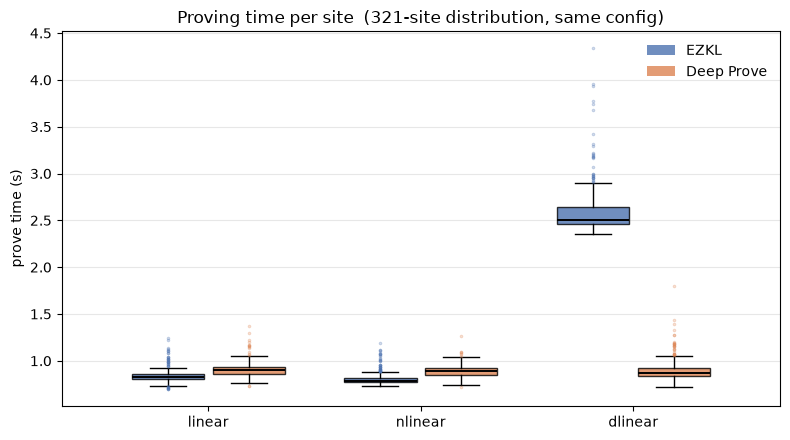

In [3]:
def grouped_box(metric, ylabel, title, logy=False, fname=None):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    width = 0.34
    for i, mdl in enumerate(MODELS):
        for j, fw in enumerate(FRAMEWORKS):
            vals = df[(df.model == mdl) & (df.framework == fw)][metric].dropna().values
            pos = i + (j - 0.5) * (width + 0.04)
            bp = ax.boxplot(vals, positions=[pos], widths=width, patch_artist=True,
                            flierprops=dict(marker=".", markersize=3, alpha=0.35,
                                            markeredgecolor=COLOR[fw]))
            bp["boxes"][0].set(facecolor=COLOR[fw], alpha=0.8)
            bp["medians"][0].set(color="black", linewidth=1.4)
    ax.set_xticks(range(len(MODELS))); ax.set_xticklabels(MODELS)
    if logy: ax.set_yscale("log")
    ax.set_ylabel(ylabel); ax.set_title(title); ax.grid(axis="y", alpha=0.3)
    handles = [plt.Rectangle((0, 0), 1, 1, facecolor=COLOR[fw], alpha=0.8) for fw in FRAMEWORKS]
    ax.legend(handles, [LABEL[fw] for fw in FRAMEWORKS], frameon=False)
    fig.tight_layout()
    if fname: fig.savefig(FIGS / fname, dpi=130, bbox_inches="tight")
    plt.show()

grouped_box("prove_s", "prove time (s)",
            "Proving time per site  (321-site distribution, same config)",
            fname="box_prove_s.png")

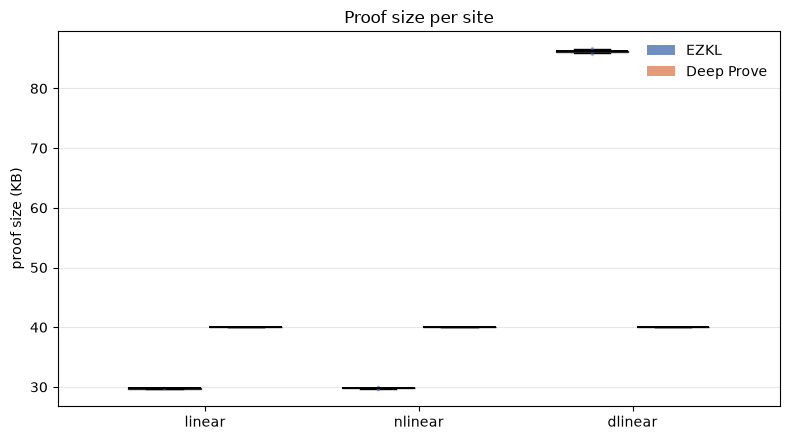

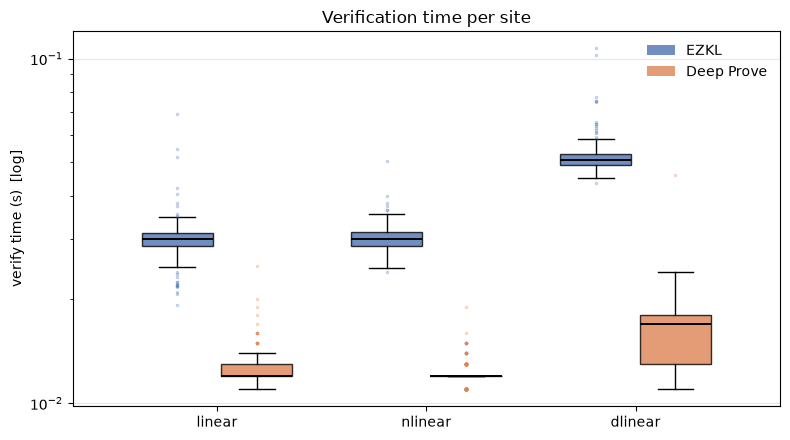

In [4]:
grouped_box("proof_kb", "proof size (KB)", "Proof size per site", fname="box_proof_kb.png")
grouped_box("verify_s", "verify time (s)  [log]", "Verification time per site", logy=True, fname="box_verify_s.png")

## 4. Median proving time (bar)

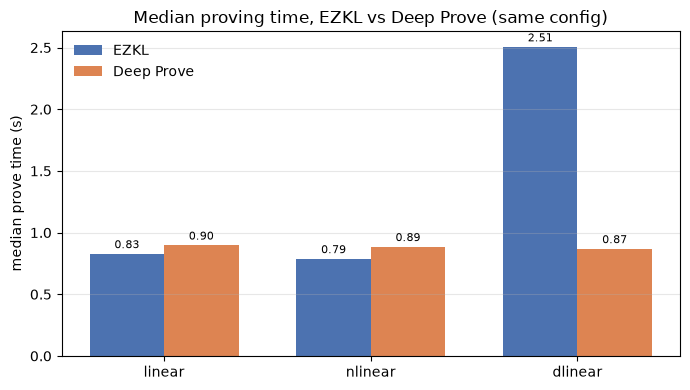

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(MODELS)); w = 0.36
for j, fw in enumerate(FRAMEWORKS):
    meds = [df[(df.model == m) & (df.framework == fw)].prove_s.median() for m in MODELS]
    bars = ax.bar(x + (j - 0.5) * w, meds, w, label=LABEL[fw], color=COLOR[fw])
    ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(MODELS); ax.set_ylabel("median prove time (s)")
ax.set_title("Median proving time, EZKL vs Deep Prove (same config)")
ax.legend(frameon=False); ax.grid(axis="y", alpha=0.3)
fig.tight_layout(); fig.savefig(FIGS / "bar_prove_med.png", dpi=130, bbox_inches="tight"); plt.show()